In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
import spectrum as sp
from matplotlib.patches import Circle
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2
e= 4.80320425e-10


In [2]:
opacTable = np.load('../output/r1200_pinhole_tde1335_inc15_opacitytable_test.npz')
noTable = np.load('../output/r1200_pinhole_tde1335_inc15.npz')

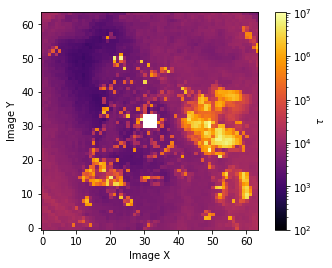

In [3]:
frequencies = np.array(opacTable['frequency'][9])
plt.imshow(opacTable['tau'][9],cmap='inferno',origin='lower',norm=colors.LogNorm(vmin=1e2))
plt.colorbar(label="$\\tau$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.savefig('../plots/tde_tau_opacityTable.png', bbox_inches='tight', dpi=300)
plt.show()

In [33]:
geodesicFile = '../output/tde_inc15_r1200_geodesics.dat'
with open(geodesicFile, 'rb') as f:
    data = np.fromfile(f)
print(data.shape)

(67611207,)


In [34]:
camx = data[:4]
u_con = data[4:8]
u_cov = data[8:12]
norm_con = data[12:16]
norm_con_c = data[16:20]
hor_con_c = data[20:24]
vert_con_c = data[24:28]

In [35]:
data[28:33]

array([8.69169476e-311, 2.12199579e-314, 4.94065646e-324, 7.76652505e+148,
       5.34235864e-315])

In [36]:
data[:100]

array([ 0.00000000e+000,  3.10582854e+002,  0.00000000e+000,
        1.15911099e+003,  1.00083299e+000, -4.31006053e-004,
        0.00000000e+000, -1.60853649e-003, -9.99167707e-001,
       -6.27863172e-020,  0.00000000e+000,  0.00000000e+000,
        1.00083299e+000,  2.58172626e-001,  0.00000000e+000,
        9.63513356e-001,  1.00000000e+000,  2.58603632e-001,
        0.00000000e+000,  9.65121893e-001,  0.00000000e+000,
        0.00000000e+000,  1.00000000e+000, -0.00000000e+000,
        0.00000000e+000, -9.65925826e-001,  0.00000000e+000,
        2.58819045e-001,  8.69169476e-311,  2.12199579e-314,
        4.94065646e-324,  7.76652505e+148,  5.34235864e-315,
       -4.08942681e-117,  5.35229892e-315,  7.76652505e+148,
        5.34235864e-315, -4.08942681e-117,  5.35229892e-315,
        7.76652505e+148,  5.34235864e-315, -4.08942681e-117,
        5.35229892e-315,  7.76652505e+148,  5.34235864e-315,
       -4.08942681e-117,  5.35229892e-315,  7.76652505e+148,
        5.34235864e-315,

In [11]:
data[-4:-1]

array([0., 0., 0.])

In [13]:
data[-42:-30]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [25]:
64*64

4096

In [27]:
np.nonzero(data[-4096:])

(array([ 430,  431,  432, ..., 2846, 2847, 2848]),)

In [28]:
4096-2848

1248

In [30]:
data[-1248]

6.0

In [ ]:
camera_pos = data[28:32]
camera_dir = data[32:36]
image_frequencies = data[36:]

array([ 8.69169476e-311,  2.12199579e-314,  4.94065646e-324,
        7.76652505e+148,  5.34235864e-315, -4.08942681e-117,
        5.35229892e-315])

In [ ]:
geodesics = pd.read_csv('../output/tde_inc15_r1200_geodesics.dat')
print(geodesics)

TypeError: read_csv() got an unexpected keyword argument 'on_bad_lines'

In [ ]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

fig,ax = plt.subplots(1,1,figsize=(6,4))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15_opacitytable_test.npz'
argumentDict['distance'] = 1200
argumentDict['mass'] = 3e6
argumentDict['frequency_num'] = 20
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 200.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

ax.plot(freqs1,freqs1*flux*eV,label='w/ opacity table')

#argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15_opacitytable_test.npz'
#flux2, freqs2 = sp.get_flux(**argumentDict)
#thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
#flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
#ax.plot(freqs2,freqs2*flux*eV,label='free-free w/ interp')


argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15.npz'
argumentDict['distance'] = 1200
flux2, freqs2 = sp.get_flux(**argumentDict)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs2,freqs2*flux*eV,label='w/o opacity table')

shaneResults = np.loadtxt('../spec.txt')
ax.plot(shaneResults[:,0],shaneResults[:,1]*1e3,label='MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('$\\nu L_\\nu$ (eV/s)')
ax.set_title('TDE Spectrum at $i = 15^\\circ$')
plt.tight_layout()
plt.show()